In [51]:
#import os
#os.environ.pop("MPLBACKEND", None)

from sentence_transformers import SentenceTransformer
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt
import os
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from umap import UMAP
from sklearn.cluster import HDBSCAN
import json
import glob
import os
import json
import random
import pickle
from sklearn.metrics.pairwise import cosine_distances
import seaborn as sns
import torch
import gc
import re

#from google.colab import drive
#drive.mount('/content/drive',force_remount=True)

POPULATION_DIR = "/scratch/mansisak/llm_optimizer/curated_initial_populations_v2"
POPULATION_DYNAMICS_RESULTS = "/scratch/mansisak/llm_optimizer/pop_dynamics"
EMBEDDING_CACHE_DIR = "/scratch/mansisak/llm_optimizer/embedding_cache"

# Use the GPU for embedding if this kernel has one visible (e.g. running inside a Slurm
# GPU allocation); every SentenceTransformer(...) call below passes device=DEVICE.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Embedding device: {DEVICE}")

# Rollout directory names in population_dynamics/ and perturb/ all start with
# "opro_<model>_...". Shared here so both analysis sections stratify consistently.
MODEL_PATTERN = re.compile(r"^opro_(gemini-25-flash|gemini-35-flash|openaigpt-oss-120b)_")
MODEL_LABELS = {
    'gemini-25-flash': 'Gemini 2.5 Flash',
    'gemini-35-flash': 'Gemini 3.5 Flash',
    'openaigpt-oss-120b': 'GPT-OSS-120B',
}
MODEL_ORDER = ['Gemini 2.5 Flash', 'Gemini 3.5 Flash', 'GPT-OSS-120B']


def extract_model_label(run_dir):
    basename = os.path.basename(run_dir.rstrip('/'))
    m = MODEL_PATTERN.match(basename)
    if not m:
        return None
    return MODEL_LABELS[m.group(1)]

Embedding device: cuda


In [52]:
def embed_with_cache(texts, model_name, cache_key, device=DEVICE, trust_remote_code=False,
                      batch_size=32, max_seq_length=None, cache_dir=EMBEDDING_CACHE_DIR):
    """SentenceTransformer.encode(), but persisted to disk keyed by (cache_key, model_name)
    so re-running a notebook cell -- or a later notebook entirely -- doesn't re-pay for
    embeddings it already computed. Cached per solution string (not per DataFrame row), so
    if a task's pool grows (e.g. new rollout runs land under cloud/ or general_rollout/)
    only the newly-seen strings get embedded; everything already cached is reused as-is.
    Embedding models differ per task (see TASK_CONFIGS), so the cache file also differs
    per model_name -- reusing gemini-vs-Qodo embeddings across tasks would be meaningless.

    Skips loading the (sometimes multi-GB, e.g. Qodo-Embed-1-1.5B) SentenceTransformer
    entirely when every requested text is already cached.
    """
    os.makedirs(cache_dir, exist_ok=True)
    safe_model_name = model_name.replace('/', '__')
    cache_path = os.path.join(cache_dir, f"{cache_key}__{safe_model_name}.pkl")

    cache = {}
    if os.path.exists(cache_path):
        with open(cache_path, 'rb') as f:
            cache = pickle.load(f)
        print(f"embed_with_cache[{cache_key}]: loaded {len(cache)} cached embeddings from {cache_path}")

    # dict.fromkeys dedupes while preserving first-seen order, same as clean_df's own dedup
    missing = [t for t in dict.fromkeys(texts) if t not in cache]

    if missing:
        print(f"embed_with_cache[{cache_key}]: embedding {len(missing)} new / {len(texts)} total "
              f"texts with {model_name}...")
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        model = SentenceTransformer(model_name, device=device, trust_remote_code=trust_remote_code)
        if max_seq_length is not None:
            model.max_seq_length = min(model.max_seq_length, max_seq_length)
        new_embeddings = model.encode(missing, show_progress_bar=True, batch_size=batch_size)
        for text, emb in zip(missing, new_embeddings):
            cache[text] = emb

        # Same GPU-memory hygiene as the rest of this notebook: free the model immediately
        # rather than waiting on Python's GC, since TASK_CONFIGS loops over several tasks
        # each with their own (sometimes multi-GB) embedding model.
        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        with open(cache_path, 'wb') as f:
            pickle.dump(cache, f)
        print(f"embed_with_cache[{cache_key}]: saved {len(cache)} embeddings to {cache_path}")
    else:
        print(f"embed_with_cache[{cache_key}]: all {len(texts)} texts already cached -- "
              f"skipping model load entirely.")

    return np.array([cache[t] for t in texts])

In [53]:
# Define your parameter settings
noise_settings = [0.0, 0.1, 0.5, 1.0]
n_settings = [3, 5, 10, 20, 0]

# List to store individual DataFrames
all_dfs = []

# Loop over every combination of n and noise
for n, noise in itertools.product(n_settings, noise_settings):
    df_path = f"/scratch/mansisak/llm_optimizer/temp_results_dir/tweet_{n}_{noise}/solution_bank.json"

    # Check if the file exists to prevent your loop from crashing on missing data
    if os.path.exists(df_path):
        # 1. Read the JSON file
        df = pd.read_json(df_path, orient='index')

        # 2. Reset index and rename columns
        df = df.reset_index()
        df.columns = ['iter_num', 'solution_str', 'score_num']

        # 3. Add tracking columns for context
        df['n'] = n
        df['noise'] = noise

        # Append to our tracking list
        all_dfs.append(df)
    else:
        print(f"Warning: File not found at {df_path}")

# Concatenate all DataFrames into one, ignoring indices to prevent duplicates
if all_dfs:
    final_df = pd.concat(all_dfs, ignore_index=True)
    print(f"Successfully combined {len(all_dfs)} files.")
else:
    print("No data was found or loaded.")

final_df.head()

Successfully combined 20 files.


,iter_num,solution_str,score_num,n,noise
0,0,Imagine getting a standing ovation for not set...,0.008827,3,0.0
1,1,Imagine getting a standing ovation for finally...,0.000833,3,0.0
2,2,Imagine getting a standing ovation for putting...,0.019719,3,0.0
3,3,Imagine getting a standing ovation for not cra...,0.004974,3,0.0
4,4,Imagine getting a standing ovation for doing y...,0.001041,3,0.0


# Create a gradient of populations w/ varying inital score vs. diversity dynamics



In [54]:
import numpy as np

# 1. Establish the bounding cutoffs for your 4 rows using the df column
score_edges = np.quantile(final_df['score_num'], [0, 0.25, 0.50, 0.75, 1.0])

# 2. Group solutions into 4 discrete rows based on their scores
rows = []
for r in range(4):
    s_min, s_max = score_edges[r], score_edges[r+1]

    # Filter the DataFrame directly using a boolean mask
    row_pool = final_df[(final_df['score_num'] >= s_min) & (final_df['score_num'] <= s_max)].copy()

    rows.append(row_pool)

for idx, r_df in enumerate(rows):
    mean_score = r_df['score_num'].mean()
    count = len(r_df)
    print(f"Row {idx+1} -> Count: {count} solutions | Average Score: {mean_score:.4f}")



Row 1 -> Count: 250 solutions | Average Score: 0.0032
Row 2 -> Count: 250 solutions | Average Score: 0.0417
Row 3 -> Count: 252 solutions | Average Score: 0.2040
Row 4 -> Count: 253 solutions | Average Score: 0.4568


In [55]:

def generate_and_save_16_populations(df, output_dir, seed=42):
    os.makedirs(output_dir, exist_ok=True)

    random.seed(seed)
    np.random.seed(seed)

    clean_df = df.drop_duplicates(subset=['solution_str']).copy()
    print(f"Pool size after deduplication: {len(clean_df)} solutions.")

    embeddings = embed_with_cache(
        clean_df['solution_str'].tolist(), model_name='all-MiniLM-L6-v2', cache_key='tweet',
    )
    clean_df['embedding'] = list(embeddings)

    score_edges = np.quantile(clean_df['score_num'], [0, 0.25, 0.50, 0.75, 1.0])
    experiment_matrix = {}

    thresholds = {
        "Col_1": (0.00, 0.15),
        "Col_2": (0.15, 0.40),
        "Col_3": (0.50, 0.75),
        "Col_4": (0.75, 1.00)
    }

    for r in range(4):
        s_min, s_max = score_edges[r], score_edges[r+1]

        if r < 3:
            row_df = clean_df[(clean_df['score_num'] >= s_min) & (clean_df['score_num'] < s_max)].copy()
        else:
            row_df = clean_df[(clean_df['score_num'] >= s_min) & (clean_df['score_num'] <= s_max)].copy()

        if len(row_df) < 15:
            print(f"Warning: Row {r+1} too small ({len(row_df)} items). Using fallback random sampling.")
            row_solutions = row_df.to_dict('records')
            for name in thresholds.keys():
                pop_key = f"Row_{r+1}_{name}"
                sampled_population = random.choices(row_solutions, k=min(10, len(row_solutions)))
                save_population_json(sampled_population, pop_key, output_dir)
                experiment_matrix[pop_key] = sampled_population
            continue

        row_embeddings = np.array(row_df['embedding'].tolist())
        row_solutions = row_df.to_dict('records')

        row_centroid = np.mean(row_embeddings, axis=0).reshape(1, -1)
        distances_to_centroid = cosine_distances(row_embeddings, row_centroid).flatten()

        for idx, dist in enumerate(distances_to_centroid):
            row_solutions[idx]['_dist_to_center'] = dist

        row_solutions_sorted = sorted(row_solutions, key=lambda x: x['_dist_to_center'])
        n_items = len(row_solutions_sorted)

        for col_name, (low_pct, high_pct) in thresholds.items():
            pop_key = f"Row_{r+1}_{col_name}"

            start_idx = int(n_items * low_pct)
            end_idx = int(n_items * high_pct)
            sub_pool = row_solutions_sorted[start_idx:end_idx]

            # Dynamic fallback expansion if semantic boundaries are too restrictive
            if len(sub_pool) < 10:
                sub_pool = row_solutions_sorted[max(0, start_idx-10) : min(n_items, end_idx+10)]

            # --- CRITICAL SCORE VARIANCE CONTROL LOOP ---
            # Sort the semantic sub-pool by score_num to find a contiguous block with SD < 0.05
            sub_pool_sorted_by_score = sorted(sub_pool, key=lambda x: x['score_num'])

            sampled_population = []
            # Use a sliding window of size 10 to find a group satisfying the variance limit
            for i in range(len(sub_pool_sorted_by_score) - 9):
                candidate_window = sub_pool_sorted_by_score[i:i+10]
                candidate_scores = [item['score_num'] for item in candidate_window]

                if np.std(candidate_scores) < 0.05:
                    sampled_population = candidate_window
                    break # Found a valid tightly-bound score cluster!

            # Fallback Guard: If no contiguous block of 10 matches SD < 0.05,
            # forcefully pick the 10 closest scores in this sub-pool to minimize variance
            if not sampled_population:
                print(f" Variance Alert: Row_{r+1}_{col_name} couldn't easily find SD < 0.05. Forcing closest scores.")
                min_sd = float('inf')
                best_idx = 0
                for i in range(len(sub_pool_sorted_by_score) - 9):
                    candidate_scores = [item['score_num'] for item in sub_pool_sorted_by_score[i:i+10]]
                    current_sd = np.std(candidate_scores)
                    if current_sd < min_sd:
                        min_sd = current_sd
                        best_idx = i
                sampled_population = sub_pool_sorted_by_score[best_idx:best_idx+10]

            # Save and clean up metrics
            #save_population_json(sampled_population, pop_key, output_dir)

            for item in sampled_population:
                item.pop('_dist_to_center', None)

            experiment_matrix[pop_key] = sampled_population

    print(f"\nSuccessfully built and saved 16 populations using seed {seed}!")
    return experiment_matrix

def save_population_json(sampled_list, pop_name, output_dir):
    print(pop_name)
    initial_pop = {}
    for idx, item in enumerate(sampled_list):
        initial_pop[str(idx)] = {
            'solution': item.get('solution_str'),
            'score': item.get('score_num'),
            'extra_info': {}
        }
    file_path = os.path.join(output_dir, f"{pop_name}.json")
    with open(file_path, 'w', encoding='utf-8') as f:
        json.dump(initial_pop, f, indent=4, ensure_ascii=False)

# Execution
experiment_populations = generate_and_save_16_populations(final_df, POPULATION_DIR, seed=42)


Pool size after deduplication: 884 solutions.
embed_with_cache[tweet]: loaded 884 cached embeddings from /scratch/mansisak/llm_optimizer/embedding_cache/tweet__all-MiniLM-L6-v2.pkl
embed_with_cache[tweet]: all 884 texts already cached -- skipping model load entirely.

Successfully built and saved 16 populations using seed 42!


In [56]:


# Lists to collect summary statistics for any further plotting
extended_summary = []

print(f"{'Population ID':<25} | {'Score (Mean ± SD)':<20} | {'Diversity Distance (Mean ± SD)':<25}")
print("-" * 76)

for pop_name, solutions_list in experiment_populations.items():
    pop_df = pd.DataFrame(solutions_list)
    embeddings = np.array(pop_df['embedding'].tolist())

    # 1. Score Calculations
    mean_score = pop_df['score_num'].mean()
    std_score = pop_df['score_num'].std() # Sample standard deviation (ddof=1)

    # 2. Pairwise Distance Calculations
    if len(embeddings) > 1:
        pairwise_dist = cosine_distances(embeddings)
        triu_idx = np.triu_indices_from(pairwise_dist, k=1)
        flat_distances = pairwise_dist[triu_idx]

        mean_div = np.mean(flat_distances)
        std_div = np.std(flat_distances) # Standard deviation of the 45 unique pairs
    else:
        mean_div = 0.0
        std_div = 0.0

    # Format and print the row cleanly
    score_str = f"{mean_score:.4f} ± {std_score:.4f}"
    div_str = f"{mean_div:.4f} ± {std_div:.4f}"
    print(f"{pop_name:<25} | {score_str:<20} | {div_str:<25}")

    # Parse string labels for tabular logging
    parts = pop_name.split('_')
    extended_summary.append({
        'Population': pop_name,
        'Row': f"Row {parts[1]}",
        'Column': f"Col {parts[3]}",
        'Score_Mean': mean_score,
        'Score_SD': std_score,
        'Diversity_Mean': mean_div,
        'Diversity_SD': std_div
    })

# Convert to DataFrame if you need to inspect or export as a CSV
extended_summary_df = pd.DataFrame(extended_summary)


Population ID             | Score (Mean ± SD)    | Diversity Distance (Mean ± SD)
----------------------------------------------------------------------------
Row_1_Col_1               | 0.0008 ± 0.0001      | 0.2450 ± 0.1304          
Row_1_Col_2               | 0.0008 ± 0.0001      | 0.4053 ± 0.1329          
Row_1_Col_3               | 0.0008 ± 0.0001      | 0.5158 ± 0.1412          
Row_1_Col_4               | 0.0007 ± 0.0001      | 0.7126 ± 0.1299          
Row_2_Col_1               | 0.0134 ± 0.0030      | 0.4520 ± 0.1652          
Row_2_Col_2               | 0.0126 ± 0.0018      | 0.5427 ± 0.1601          
Row_2_Col_3               | 0.0115 ± 0.0021      | 0.5638 ± 0.1692          
Row_2_Col_4               | 0.0105 ± 0.0013      | 0.7098 ± 0.2177          
Row_3_Col_1               | 0.1362 ± 0.0182      | 0.2246 ± 0.1089          
Row_3_Col_2               | 0.0922 ± 0.0098      | 0.4627 ± 0.1659          
Row_3_Col_3               | 0.0984 ± 0.0154      | 0.5627 ± 0.1380     

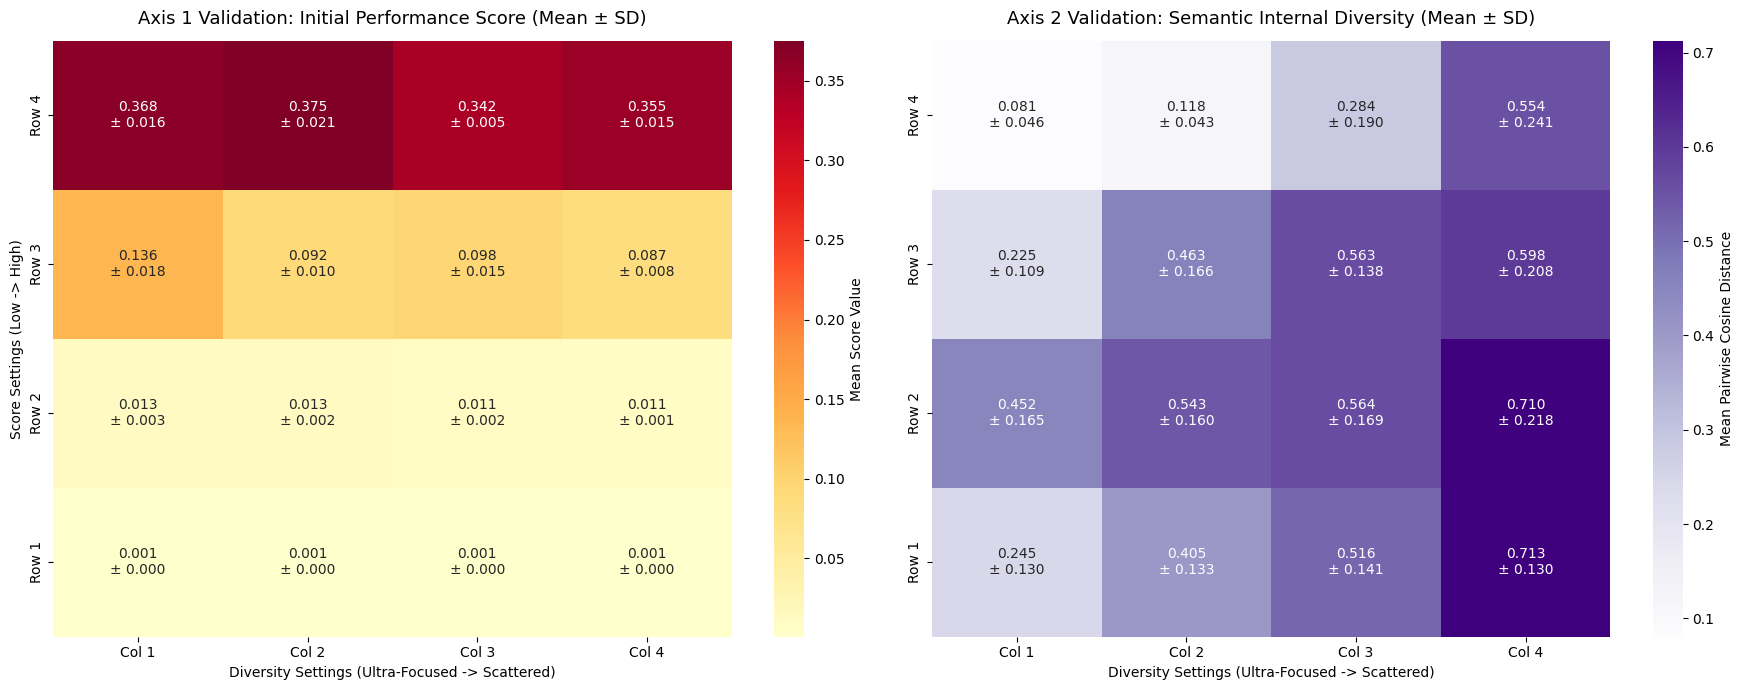

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Pivot all metrics into 4x4 matrix forms
score_mean_mat = extended_summary_df.pivot(index='Row', columns='Column', values='Score_Mean')
score_sd_mat = extended_summary_df.pivot(index='Row', columns='Column', values='Score_SD')
div_mean_mat = extended_summary_df.pivot(index='Row', columns='Column', values='Diversity_Mean')
div_sd_mat = extended_summary_df.pivot(index='Row', columns='Column', values='Diversity_SD')

# 2. Enforce explicit order to match your grid layout
row_order = ['Row 4', 'Row 3', 'Row 2', 'Row 1']
col_order = ['Col 1', 'Col 2', 'Col 3', 'Col 4']

score_mean_mat = score_mean_mat.reindex(index=row_order, columns=col_order)
score_sd_mat = score_sd_mat.reindex(index=row_order, columns=col_order)
div_mean_mat = div_mean_mat.reindex(index=row_order, columns=col_order)
div_sd_mat = div_sd_mat.reindex(index=row_order, columns=col_order)

# 3. Create custom string label matrices combining Mean and SD
score_labels = score_mean_mat.copy().astype(str)
div_labels = div_mean_mat.copy().astype(str)

for r in row_order:
    for c in col_order:
        score_labels.loc[r, c] = f"{score_mean_mat.loc[r, c]:.3f}\n± {score_sd_mat.loc[r, c]:.3f}"
        div_labels.loc[r, c] = f"{div_mean_mat.loc[r, c]:.3f}\n± {div_sd_mat.loc[r, c]:.3f}"

# 4. Initialize the plot canvas
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- PANEL 1: INITIAL PERFORMANCE SCORE ---
sns.heatmap(score_mean_mat,
            annot=score_labels.values,  # Pass our formatted text matrix
            fmt="",                     # Required string formatting flag
            cmap="YlOrRd",
            ax=axes[0],
            annot_kws={"size": 10},     # Font size adjustment for 2-line annotations
            cbar_kws={'label': 'Mean Score Value'})
axes[0].set_title('Axis 1 Validation: Initial Performance Score (Mean ± SD)', fontsize=13, pad=12)
axes[0].set_xlabel('Diversity Settings (Ultra-Focused -> Scattered)')
axes[0].set_ylabel('Score Settings (Low -> High)')

# --- PANEL 2: INITIAL SEMANTIC DIVERSITY ---
sns.heatmap(div_mean_mat,
            annot=div_labels.values,
            fmt="",
            cmap="Purples",
            ax=axes[1],
            annot_kws={"size": 10},
            cbar_kws={'label': 'Mean Pairwise Cosine Distance'})
axes[1].set_title('Axis 2 Validation: Semantic Internal Diversity (Mean ± SD)', fontsize=13, pad=12)
axes[1].set_xlabel('Diversity Settings (Ultra-Focused -> Scattered)')
axes[1].set_ylabel('')  # Clear redundant label

plt.tight_layout()
plt.show()


# Generalize initial-population curation to other tasks

Reuse the same score-x-diversity grid approach above for **cantbelate**, **cloudcast**, and **prompt** (drop dataset only), instead of just tweet.

Unlike tweet, these tasks never had a dedicated noise-sweep pool generated (`temp_results_dir/tweet_{n}_{noise}/solution_bank.json`). Instead we pool candidate solutions from every already-completed rollout run for that task under `cloud/` (cantbelate, cloudcast) or `general_rollout/` (prompt), reading each run's `long_running_solution_bank.json` -- the same `{"<idx>": {"solution":..., "score":...}}` schema used everywhere else in this pipeline.

Notes:
- `prompt`'s gsm8k dataset is intentionally excluded: only ~13 unique solutions across 3 runs, too thin to bin into any meaningful grid. Only `prompt`/drop (~112 unique) is curated here.
- cantbelate/cloudcast solutions are full Python programs (800-2000+ chars), well beyond `all-MiniLM-L6-v2`'s 256-token context, so they use a code-specialized embedding model (`Qodo/Qodo-Embed-1-1.5B`, 131k-token context) instead. It's built on a standard `qwen2` architecture rather than custom remote-code (unlike `jinaai/jina-embeddings-v2-base-code`, which needed `trust_remote_code=True` and turned out to be incompatible with this environment's `transformers` 5.x -- its legacy custom modeling file assumed internals transformers 5.x removed/changed).
- cantbelate (~4,900 unique) and cloudcast (~1,250 unique) have enough pooled data for a tight 4x4 grid; prompt/drop (~112 unique) does not, so grid size is auto-selected per task rather than hardcoded.


In [62]:
CLOUD_DIR = "/scratch/mansisak/llm_optimizer/cloud"
GENERAL_ROLLOUT_DIR = "/scratch/mansisak/llm_optimizer/general_rollout"

TASK_CONFIGS = {
    'cantbelate': dict(
        source_dir=CLOUD_DIR, task_token='cantbelate', dataset=None,
        embed_model='Qodo/Qodo-Embed-1-1.5B', trust_remote_code=False,
        # cantbelate/cloudcast solutions are full Python programs that can run to several
        # thousand tokens; Qodo-Embed-1-1.5B's 131k-token context means encode() will
        # happily batch them at full length with zero truncation, and self-attention
        # memory scales quadratically with sequence length -- a handful of long solutions
        # landing in the same default-sized (32) batch is enough to OOM a single 44GB GPU
        # on its own. Cap both the per-call batch size and the max sequence length actually
        # fed to the model so one batch's peak memory stays bounded no matter how long any
        # individual solution is (short natural-language tasks below don't need this).
        encode_batch_size=8, max_seq_length=4096,
        # Explicit 4 score bins x 3 diversity bins for this task, rather than letting
        # choose_grid_size() auto-pick -- both tasks have plenty of pooled data to support
        # a 4x4 grid (which is what choose_grid_size() would pick, since it always prefers
        # the largest candidate whose density check passes), but 4x3 is wanted here instead.
        grid_size=(4, 3),
        # pop_size left at generate_and_save_population_grid's default (10).
    ),
    'cloudcast': dict(
        source_dir=CLOUD_DIR, task_token='cloudcast', dataset=None,
        embed_model='Qodo/Qodo-Embed-1-1.5B', trust_remote_code=False,
        encode_batch_size=8, max_seq_length=4096,
        grid_size=(3, 3),
        pop_size=5,
    ),
    'prompt_drop': dict(
        source_dir=GENERAL_ROLLOUT_DIR, task_token='prompt', dataset='drop',
        embed_model='all-MiniLM-L6-v2', trust_remote_code=False,
        encode_batch_size=32, max_seq_length=None,  # MiniLM's own 256-token cap is already tight
        # No grid_size override: pool is thin (~112 unique), so let choose_grid_size()
        # auto-pick based on actual density instead of hardcoding. It's also handed this
        # task's pop_size below, so the density check it does (unique / cells >= pop_size *
        # safety_factor) reflects the smaller populations we're actually asking for here,
        # not the default of 10.
        pop_size=5,
    ),
    # prompt/gsm8k intentionally omitted: only ~13 unique solutions across 3 runs,
    # too thin to bin into a meaningful grid.
}


def load_pool_from_rollout_dirs(source_dir, task_token, dataset=None):
    """Pool solutions across every already-completed rollout run for `task_token`
    under `source_dir`, the same way the tweet pool above is pooled across its
    noise-sweep directories -- just sourced from each run's
    `long_running_solution_bank.json` instead of a dedicated `solution_bank.json`,
    since cantbelate/cloudcast/prompt never had a standalone noise-sweep run.
    `dataset`, when set, restricts to run dirs ending in `_<dataset>` (only
    meaningful for `prompt`, whose dataset -- drop vs. gsm8k -- changes what's
    being optimized; cantbelate/cloudcast dirs also end in a fixed `_drop`
    token, but it's an irrelevant default for those tasks so it's ignored here).
    """
    run_dirs = glob.glob(os.path.join(source_dir, f"*_{task_token}_*/"))
    if dataset is not None:
        run_dirs = [d for d in run_dirs if d.rstrip('/').endswith(f"_{dataset}")]

    all_dfs = []
    for run_dir in run_dirs:
        bank_path = os.path.join(run_dir, "long_running_solution_bank.json")
        if not os.path.exists(bank_path):
            print(f"Warning: File not found at {bank_path}")
            continue
        df = pd.read_json(bank_path, orient='index')
        df = df.reset_index()[['index', 'solution', 'score']]
        df.columns = ['iter_num', 'solution_str', 'score_num']
        df['run_dir'] = os.path.basename(run_dir.rstrip('/'))
        all_dfs.append(df)

    label = task_token + (f"/{dataset}" if dataset else "")
    if not all_dfs:
        print(f"No data found for {label} in {source_dir}")
        return pd.DataFrame(columns=['iter_num', 'solution_str', 'score_num', 'run_dir'])

    pool_df = pd.concat(all_dfs, ignore_index=True)

    # cantbelate/cloudcast score crashed/invalid rollouts with a FAILED_SCORE sentinel
    # (-100_000.0, see llm_optimizer/tasks/{cant_be_late,cloud_cast}_utils/simulation.py)
    # rather than dropping them from the bank. They're rare (well under 2% of any pool
    # seen so far) but sit far outside the real score range, so they'd otherwise anchor
    # the lowest score-quantile edge and could get scooped into a "low scoring" population
    # via the small-cell random-sampling fallback. Filter them out here the same way
    # opro.py's apply_noise_to_scores already treats the sentinel as not a real score.
    n_before = len(pool_df)
    pool_df = pool_df[pool_df['score_num'] > -99_999].reset_index(drop=True)
    n_failed = n_before - len(pool_df)
    if n_failed:
        print(f"{label}: dropped {n_failed} failed-rollout sentinel score(s).")

    print(f"{label}: pooled {len(run_dirs)} run dirs -> {len(pool_df)} rows, "
          f"{pool_df['solution_str'].nunique()} unique solutions.")
    return pool_df


In [63]:
def choose_grid_size(pool_df, candidates=((4, 4), (3, 3)), pop_size=10, safety_factor=1.5):
    """Auto-pick the largest (n_rows, n_cols) grid the deduped pool can support:
    the largest candidate whose estimated cell size (unique solutions / total
    cells) comfortably clears `pop_size` -- so most cells can be filled without
    leaning on the small-cell random-sampling fallback. Falls back to the
    smallest candidate (with a warning) if even that isn't met.

    Only consulted when a task's TASK_CONFIGS entry doesn't set an explicit
    `grid_size` -- see the loop below. Picking a specific grid (e.g. cantbelate/
    cloudcast's 4x3) isn't something this function can be steered into via
    `candidates`: it always returns the *first* candidate whose density check
    passes, so appending a smaller grid after (4, 4) never gets reached by any
    pool dense enough to satisfy (4, 4) in the first place."""
    n_unique = pool_df.drop_duplicates(subset=['solution_str'])['solution_str'].nunique()
    for n_rows, n_cols in candidates:
        min_cell_estimate = n_unique / (n_rows * n_cols)
        if min_cell_estimate >= pop_size * safety_factor:
            print(f"choose_grid_size: {n_unique} unique solutions -> {n_rows}x{n_cols} grid "
                  f"(~{min_cell_estimate:.0f} solutions/cell est.)")
            return n_rows, n_cols

    n_rows, n_cols = candidates[-1]
    print(f"choose_grid_size: {n_unique} unique solutions is thin even for the smallest "
          f"candidate grid {n_rows}x{n_cols} -- expect the small-cell fallback to kick in "
          f"for several cells.")
    return n_rows, n_cols


def generate_and_save_population_grid(df, output_dir, embed_model_name, n_rows, n_cols,
                                       pop_size=10, sd_threshold=0.05, seed=42,
                                       trust_remote_code=False, encode_batch_size=32,
                                       max_seq_length=None, cache_key=None):
    """Generalized version of generate_and_save_16_populations above: same
    dedup -> embed -> score-quantile rows -> distance-to-centroid columns ->
    score-SD-controlled sampling pipeline, but with configurable grid
    dimensions instead of a hardcoded 4x4, and a pluggable embedding model
    (long-context code embeddings for cantbelate/cloudcast vs. MiniLM for
    short natural-language text). Diversity-column thresholds are contiguous,
    evenly spaced percentile bands here -- a deliberate simplification of the
    hand-tuned, intentionally-gapped 4-column thresholds above, which were
    tuned specifically for n_cols=4 and don't generalize to n_cols=3.

    Embeddings go through embed_with_cache (disk-cached per solution string),
    keyed by `cache_key` -- defaults to output_dir's basename (i.e. the task
    name, since callers pass output_dir=os.path.join(POPULATION_DIR, task_name))
    so re-running this cell, or adding new rollout runs to an existing task's
    pool, doesn't re-embed solutions already seen."""
    os.makedirs(output_dir, exist_ok=True)

    random.seed(seed)
    np.random.seed(seed)

    clean_df = df.drop_duplicates(subset=['solution_str']).copy()
    print(f"Pool size after deduplication: {len(clean_df)} solutions.")

    if cache_key is None:
        cache_key = os.path.basename(output_dir.rstrip('/'))

    embeddings = embed_with_cache(
        clean_df['solution_str'].tolist(), model_name=embed_model_name, cache_key=cache_key,
        trust_remote_code=trust_remote_code, batch_size=encode_batch_size,
        max_seq_length=max_seq_length,
    )
    clean_df['embedding'] = list(embeddings)

    score_edges = np.quantile(clean_df['score_num'], np.linspace(0, 1, n_rows + 1))
    col_edges = np.linspace(0, 1, n_cols + 1)
    experiment_matrix = {}
    min_row_size = pop_size * 1.5

    for r in range(n_rows):
        s_min, s_max = score_edges[r], score_edges[r + 1]

        if r < n_rows - 1:
            row_df = clean_df[(clean_df['score_num'] >= s_min) & (clean_df['score_num'] < s_max)].copy()
        else:
            row_df = clean_df[(clean_df['score_num'] >= s_min) & (clean_df['score_num'] <= s_max)].copy()

        if len(row_df) < min_row_size:
            print(f"Warning: Row {r+1} too small ({len(row_df)} items). Using fallback random sampling.")
            row_solutions = row_df.to_dict('records')
            for c in range(n_cols):
                pop_key = f"Row_{r+1}_Col_{c+1}"
                sampled_population = random.choices(row_solutions, k=min(pop_size, len(row_solutions)))
                save_population_json(sampled_population, pop_key, output_dir)
                experiment_matrix[pop_key] = sampled_population
            continue

        row_embeddings = np.array(row_df['embedding'].tolist())
        row_solutions = row_df.to_dict('records')

        row_centroid = np.mean(row_embeddings, axis=0).reshape(1, -1)
        distances_to_centroid = cosine_distances(row_embeddings, row_centroid).flatten()

        for idx, dist in enumerate(distances_to_centroid):
            row_solutions[idx]['_dist_to_center'] = dist

        row_solutions_sorted = sorted(row_solutions, key=lambda x: x['_dist_to_center'])
        n_items = len(row_solutions_sorted)

        for c in range(n_cols):
            pop_key = f"Row_{r+1}_Col_{c+1}"
            low_pct, high_pct = col_edges[c], col_edges[c + 1]

            start_idx = int(n_items * low_pct)
            end_idx = int(n_items * high_pct)
            sub_pool = row_solutions_sorted[start_idx:end_idx]

            # Dynamic fallback expansion if semantic boundaries are too restrictive
            if len(sub_pool) < pop_size:
                sub_pool = row_solutions_sorted[max(0, start_idx - pop_size): min(n_items, end_idx + pop_size)]

            # --- CRITICAL SCORE VARIANCE CONTROL LOOP ---
            # Sort the semantic sub-pool by score_num to find a contiguous block with SD < sd_threshold
            sub_pool_sorted_by_score = sorted(sub_pool, key=lambda x: x['score_num'])

            sampled_population = []
            for i in range(len(sub_pool_sorted_by_score) - pop_size + 1):
                candidate_window = sub_pool_sorted_by_score[i:i + pop_size]
                candidate_scores = [item['score_num'] for item in candidate_window]

                if np.std(candidate_scores) < sd_threshold:
                    sampled_population = candidate_window
                    break  # Found a valid tightly-bound score cluster!

            # Fallback Guard: if no contiguous block of pop_size matches SD < sd_threshold
            # (or the sub-pool is smaller than pop_size), forcefully pick the closest scores.
            if not sampled_population:
                print(f" Variance Alert: Row_{r+1}_Col_{c+1} couldn't easily find SD < {sd_threshold}. "
                      f"Forcing closest scores.")
                min_sd = float('inf')
                best_idx = 0
                for i in range(len(sub_pool_sorted_by_score) - pop_size + 1):
                    candidate_scores = [item['score_num'] for item in sub_pool_sorted_by_score[i:i + pop_size]]
                    current_sd = np.std(candidate_scores)
                    if current_sd < min_sd:
                        min_sd = current_sd
                        best_idx = i
                sampled_population = sub_pool_sorted_by_score[best_idx:best_idx + pop_size]

            save_population_json(sampled_population, pop_key, output_dir)

            for item in sampled_population:
                item.pop('_dist_to_center', None)

            experiment_matrix[pop_key] = sampled_population

    print(f"\nSuccessfully built and saved {n_rows * n_cols} populations "
          f"({n_rows}x{n_cols}) using seed {seed}!")
    return experiment_matrix


In [64]:
def summarize_and_plot_population_grid(populations, n_rows, n_cols, task_label):
    """Generalized version of the score/diversity summary + validation heatmap
    cells above (score/diversity table -> pivot -> side-by-side heatmaps),
    parameterized on grid shape and task label instead of assuming a fixed
    4x4 tweet grid."""
    summary = []
    for pop_name, solutions_list in populations.items():
        pop_df = pd.DataFrame(solutions_list)
        embeddings = np.array(pop_df['embedding'].tolist())

        mean_score = pop_df['score_num'].mean()
        std_score = pop_df['score_num'].std()

        if len(embeddings) > 1:
            pairwise_dist = cosine_distances(embeddings)
            triu_idx = np.triu_indices_from(pairwise_dist, k=1)
            flat_distances = pairwise_dist[triu_idx]
            mean_div = np.mean(flat_distances)
            std_div = np.std(flat_distances)
        else:
            mean_div = std_div = 0.0

        parts = pop_name.split('_')
        summary.append({
            'Population': pop_name,
            'Row': f"Row {parts[1]}",
            'Column': f"Col {parts[3]}",
            'Score_Mean': mean_score,
            'Score_SD': std_score,
            'Diversity_Mean': mean_div,
            'Diversity_SD': std_div,
        })
    summary_df = pd.DataFrame(summary)

    row_order = [f'Row {i}' for i in range(n_rows, 0, -1)]
    col_order = [f'Col {i}' for i in range(1, n_cols + 1)]

    score_mean_mat = summary_df.pivot(index='Row', columns='Column', values='Score_Mean').reindex(index=row_order, columns=col_order)
    score_sd_mat = summary_df.pivot(index='Row', columns='Column', values='Score_SD').reindex(index=row_order, columns=col_order)
    div_mean_mat = summary_df.pivot(index='Row', columns='Column', values='Diversity_Mean').reindex(index=row_order, columns=col_order)
    div_sd_mat = summary_df.pivot(index='Row', columns='Column', values='Diversity_SD').reindex(index=row_order, columns=col_order)

    score_labels = score_mean_mat.copy().astype(str)
    div_labels = div_mean_mat.copy().astype(str)
    for r in row_order:
        for c in col_order:
            score_labels.loc[r, c] = f"{score_mean_mat.loc[r, c]:.3f}\n± {score_sd_mat.loc[r, c]:.3f}"
            div_labels.loc[r, c] = f"{div_mean_mat.loc[r, c]:.3f}\n± {div_sd_mat.loc[r, c]:.3f}"

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    sns.heatmap(score_mean_mat, annot=score_labels.values, fmt="", cmap="YlOrRd", ax=axes[0],
                annot_kws={"size": 10}, cbar_kws={'label': 'Mean Score Value'})
    axes[0].set_title(f'{task_label}: Initial Performance Score (Mean ± SD)', fontsize=13, pad=12)
    axes[0].set_xlabel('Diversity Settings (Ultra-Focused -> Scattered)')
    axes[0].set_ylabel('Score Settings (Low -> High)')

    sns.heatmap(div_mean_mat, annot=div_labels.values, fmt="", cmap="Purples", ax=axes[1],
                annot_kws={"size": 10}, cbar_kws={'label': 'Mean Pairwise Cosine Distance'})
    axes[1].set_title(f'{task_label}: Semantic Internal Diversity (Mean ± SD)', fontsize=13, pad=12)
    axes[1].set_xlabel('Diversity Settings (Ultra-Focused -> Scattered)')
    axes[1].set_ylabel('')

    plt.tight_layout()
    plt.show()

    return summary_df



=== cantbelate ===
cantbelate: dropped 6 failed-rollout sentinel score(s).
cantbelate: pooled 12 run dirs -> 6187 rows, 5551 unique solutions.
Using explicit grid_size override for cantbelate: 4x3
Pool size after deduplication: 5551 solutions.
embed_with_cache[cantbelate]: loaded 5551 cached embeddings from /scratch/mansisak/llm_optimizer/embedding_cache/cantbelate__Qodo__Qodo-Embed-1-1.5B.pkl
embed_with_cache[cantbelate]: all 5551 texts already cached -- skipping model load entirely.
Row_1_Col_1
Row_1_Col_2
Row_1_Col_3
Row_2_Col_1
Row_2_Col_2
Row_2_Col_3
Row_3_Col_1
Row_3_Col_2
Row_3_Col_3
Row_4_Col_1
Row_4_Col_2
Row_4_Col_3

Successfully built and saved 12 populations (4x3) using seed 42!


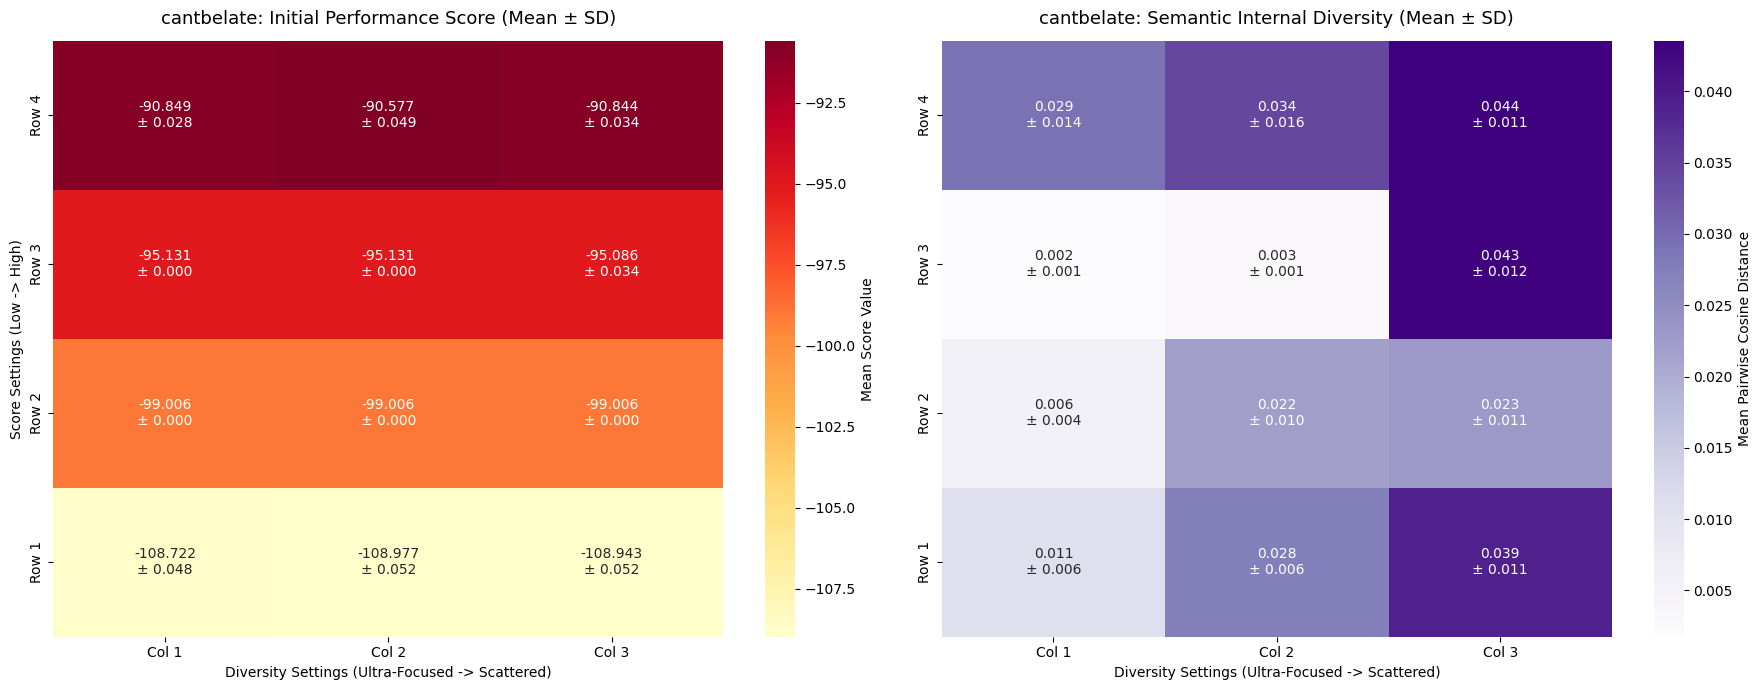


=== cloudcast ===
cloudcast: dropped 37 failed-rollout sentinel score(s).
cloudcast: pooled 12 run dirs -> 2069 rows, 2044 unique solutions.
Using explicit grid_size override for cloudcast: 3x3
Pool size after deduplication: 2044 solutions.
embed_with_cache[cloudcast]: loaded 2044 cached embeddings from /scratch/mansisak/llm_optimizer/embedding_cache/cloudcast__Qodo__Qodo-Embed-1-1.5B.pkl
embed_with_cache[cloudcast]: all 2044 texts already cached -- skipping model load entirely.
Row_1_Col_1
Row_1_Col_2
Row_1_Col_3
Row_2_Col_1
Row_2_Col_2
Row_2_Col_3
Row_3_Col_1
Row_3_Col_2
Row_3_Col_3

Successfully built and saved 9 populations (3x3) using seed 42!


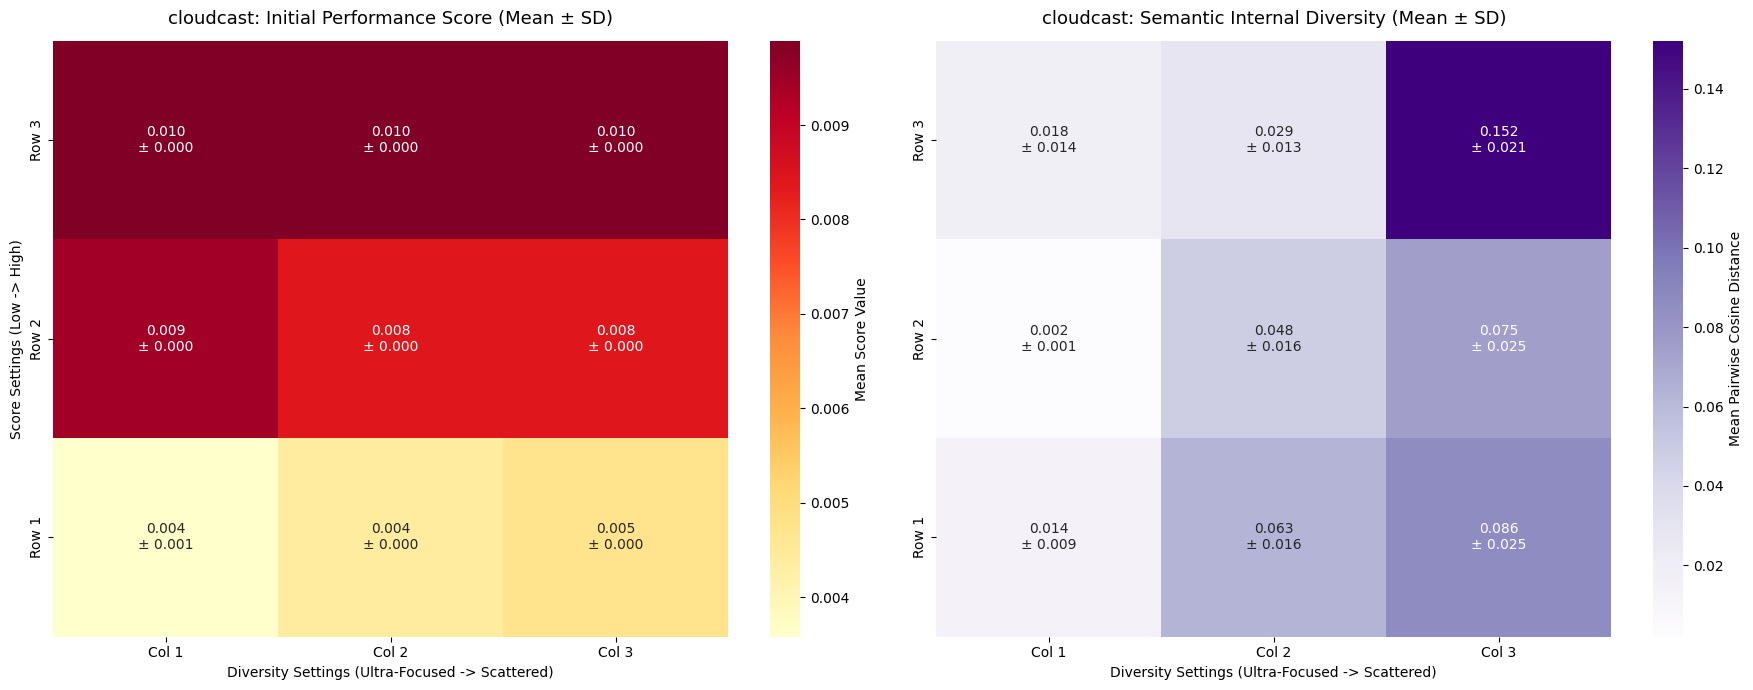


=== prompt_drop ===
prompt/drop: pooled 4 run dirs -> 120 rows, 112 unique solutions.
choose_grid_size: 112 unique solutions -> 3x3 grid (~12 solutions/cell est.)
Pool size after deduplication: 112 solutions.
embed_with_cache[prompt_drop]: loaded 112 cached embeddings from /scratch/mansisak/llm_optimizer/embedding_cache/prompt_drop__all-MiniLM-L6-v2.pkl
embed_with_cache[prompt_drop]: all 112 texts already cached -- skipping model load entirely.
Row_1_Col_1
Row_1_Col_2
Row_1_Col_3
Row_2_Col_1
Row_2_Col_2
Row_2_Col_3
Row_3_Col_1
Row_3_Col_2
Row_3_Col_3

Successfully built and saved 9 populations (3x3) using seed 42!


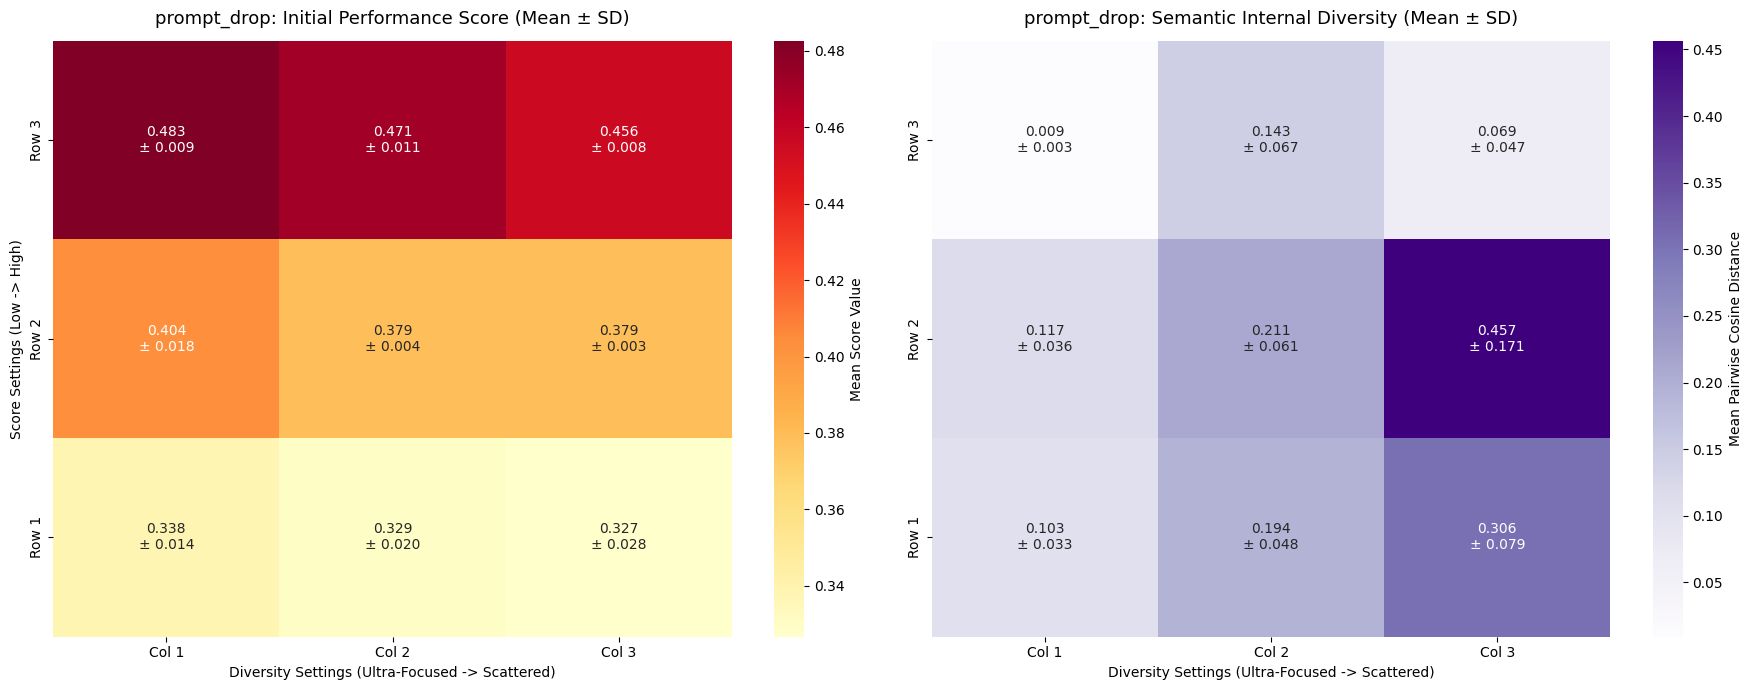

In [65]:
all_task_pools = {}
all_task_grids = {}
all_task_populations = {}
all_task_summaries = {}

for task_name, cfg in TASK_CONFIGS.items():
    print(f"\n=== {task_name} ===")
    pool_df = load_pool_from_rollout_dirs(cfg['source_dir'], cfg['task_token'], cfg['dataset'])
    if pool_df.empty:
        print(f"Skipping {task_name}: no pool data found.")
        continue
    all_task_pools[task_name] = pool_df

    pop_size = cfg.get('pop_size', 10)

    if cfg.get('grid_size') is not None:
        n_rows, n_cols = cfg['grid_size']
        print(f"Using explicit grid_size override for {task_name}: {n_rows}x{n_cols}")
    else:
        n_rows, n_cols = choose_grid_size(pool_df, pop_size=pop_size)
    all_task_grids[task_name] = (n_rows, n_cols)

    # Nested per-task output dir (curated_initial_populations_v2/<task_name>/) so these
    # new populations don't collide with tweet's existing flat Row_i_Col_j.json files,
    # and so get_args_for_pop_dynamics's non-recursive os.listdir glob still works
    # unmodified when pointed at one of these subdirs. Suffix with _pop<N> whenever
    # pop_size deviates from the 10-per-cell default -- get_args_for_pop_dynamics just
    # lists whatever *.json files sit in the directory it's pointed at, so a differently
    # sized population run under the *same* task_name dir would silently overwrite the
    # previous run's Row_i_Col_j.json files (same names) instead of coexisting with them.
    dir_name = task_name if pop_size == 10 else f"{task_name}_pop{pop_size}"
    output_dir = os.path.join(POPULATION_DIR, dir_name)
    populations = generate_and_save_population_grid(
        pool_df, output_dir, cfg['embed_model'], n_rows=n_rows, n_cols=n_cols,
        pop_size=pop_size,
        seed=42, trust_remote_code=cfg['trust_remote_code'],
        encode_batch_size=cfg.get('encode_batch_size', 32),
        max_seq_length=cfg.get('max_seq_length'),
        # Embedding cache is keyed on task identity, not pop_size (pop_size only affects
        # how the already-embedded pool is sliced into populations) -- pin it to task_name
        # explicitly so pop5 reruns still hit the same cache the pop10 run built instead of
        # deriving a different key from the now-suffixed output_dir basename.
        cache_key=task_name,
    )
    all_task_populations[task_name] = populations

    summary_df = summarize_and_plot_population_grid(populations, n_rows, n_cols, task_name)
    all_task_summaries[task_name] = summary_df
